## Imports and Helpers

In [1]:
import json
import os
import random
from collections import namedtuple
from concurrent.futures import ThreadPoolExecutor
from datetime import datetime
from glob import glob
from importlib import reload

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from tqdm.auto import tqdm
from IPython.display import HTML, clear_output

from data_readers.infrared import InfraredData
from data_readers.radar import RadarData
from data_readers.name_map import MOTION_MAP, ACTIVITY_MAP, EMOTION_MAP
# from models.contrastive_modality_pairs.model import PointCloudEncoder, TemporalDecoder
from models.contrastive_modality_pairs import model as M
from models.contrastive_modality_pairs import layers as L
M= reload(M)
L= reload(L)

np   .set_printoptions(precision=3, suppress=True)
torch.set_printoptions(precision=3, sci_mode=False)

DATASET_PATH = os.path.abspath("../../../RF-Behavior")
DATASET_PATH, os.path.exists(DATASET_PATH)

RADAR_BIN_FPS = 10

In [2]:
BATCH_SIZE = 16

Split = namedtuple("Split", ["train", "val", "test"])
Batch = namedtuple("Batch", ["embeddings", "input_seq", "output_seq"])

def split_behaviors(l, val, test):
    random.seed(42)
    random.shuffle(l)
    test_behaviors  = sorted(l[ :test])
    val_behaviors   = sorted(l[test:test+val])
    train_behaviors = sorted(l[test+val: ])
    return train_behaviors, val_behaviors, test_behaviors

def map_to_name(l):
    return [MOTION_MAP.get(m, ACTIVITY_MAP.get(m, EMOTION_MAP.get(m, "UNKNOWN"))) for m in l]

def behavior_name_from_path(path):
    return map_to_name([os.path.normpath(path).split(os.sep)[-2]])[0]

def make_radar_path(campaign, user, behavior, repetition):
    path = os.path.abspath(f"{DATASET_PATH}/Radar/{campaign}/{user}/{behavior}/{repetition}")
    if not os.path.exists(path):
        path = os.path.abspath("/0".join(os.path.split(path)))
    if os.path.exists(path):
        return glob(f"{path}/*.pkl")
    # print("Radar path does not exist:", path)
    return None

def make_infrared_path(campaign, user, behavior, repetition):
    path = os.path.abspath(f"{DATASET_PATH}/InfraredCam/InfraredCam/{campaign}/{user}/{behavior}/{repetition}.csv")
    if os.path.exists(path):
        return path
    # print("Infrared path does not exist:", path)
    return None

## train-val-test split

split behavior IDs

In [3]:
motions = Split(*split_behaviors(list(MOTION_MAP.keys()), val=2, test=4))
activities = Split(*split_behaviors(list(ACTIVITY_MAP.keys()), val=1, test=2))
emotions = Split(*split_behaviors(list(EMOTION_MAP.keys()), val=1, test=2))

print("===== Motions: =====", f"TEST  ={map_to_name(motions.test)}", f"VALID ={map_to_name(motions.val)}", f"TRAIN ={map_to_name(motions.train)}", sep="\n")
print("\n===== Activities: =====", f"TEST  ={map_to_name(activities.test)}", f"VALID ={map_to_name(activities.val)}", f"TRAIN ={map_to_name(activities.train)}", sep="\n")
print("\n===== Emotions: =====", f"TEST  ={map_to_name(emotions.test)}", f"VALID ={map_to_name(emotions.val)}", f"TRAIN ={map_to_name(emotions.train)}", sep="\n")

===== Motions: =====
TEST  =['push', 'lateral-to-front', 'left-arm-circle', 'circle-clockwise']
VALID =['arms-swing', 'two-hand-lateral-raise']
TRAIN =['lateral-raise', 'push-down', 'lift', 'pull', 'swipe-right', 'swipe-left', 'throw', 'two-hand-throw', 'two-hand-push', 'two-hand-pull', 'right-arm-circle', 'two-hand-outward-circles', 'two-hand-inward-circles', 'two-hand-lateral-to-front', 'circle-counter-clockwise']

===== Activities: =====
TEST  =['sitting', 'playing-badminton']
VALID =['lying']
TRAIN =['walking', 'running', 'ascending-stairs', 'descending-stairs', 'passing-basketball', 'kick-floor-ball', 'kick-football']

===== Emotions: =====
TEST  =['distraction', 'relaxation']
VALID =['stress']
TRAIN =['focus', 'depression', 'excitement']


<sup>todo: split users</sup><br>
split file paths

In [4]:
instances = [os.path.normpath(p).split(os.sep)[-4:]for p in glob(f"{DATASET_PATH}/InfraredCam/InfraredCam/C*/U*/[MAE]*/*.csv")]
instances = sorted(tuple(p[:3] + [p[3].rsplit(".", 1)[0]]) for p in instances)
len(instances), instances[:2]

(6327, [('C1', 'U01', 'M01', '01'), ('C1', 'U01', 'M01', '02')])

In [5]:
path_dfs = Split(
    pd.DataFrame(columns=["campaign", "behavior", "user", "repetition", "radar_frame_count", "infrared_frame_count", "radar_path", "infrared_path"]),
    pd.DataFrame(columns=["campaign", "behavior", "user", "repetition", "radar_frame_count", "infrared_frame_count", "radar_path", "infrared_path"]),
    pd.DataFrame(columns=["campaign", "behavior", "user", "repetition", "radar_frame_count", "infrared_frame_count", "radar_path", "infrared_path"]),
)

def process_instance(instance):
    campaign, user, behavior, repetition = instance
    for i in range(3):
        if behavior in motions[i] + activities[i] + emotions[i]:
            r_path = make_radar_path(campaign, user, behavior, repetition)
            ir_path = make_infrared_path(campaign, user, behavior, repetition)
            if r_path is not None and ir_path is not None:
                radar_frame_count, infrared_frame_count = None, None
                # radar_frame_count = len(RadarData.read_from_path(r_path , normalize=True).bin(fps=RADAR_BIN_FPS).points)
                # infrared_frame_count = InfraredData.read_from_path(ir_path).landmarks.shape[0]
                return (campaign, behavior, user, repetition, radar_frame_count, infrared_frame_count, r_path, ir_path, i)
    return None

with ThreadPoolExecutor(max_workers=16) as executor:
    results = list(tqdm(executor.map(process_instance, instances), total=len(instances)))

for res in results:
    if res is not None:
        campaign, behavior, user, repetition, radar_frame_count, infrared_frame_count, r_path, ir_path, split_idx = res
        path_dfs[split_idx].loc[len(path_dfs[split_idx])] = [campaign, behavior, user, repetition, radar_frame_count, infrared_frame_count, r_path, ir_path]

# path_dfs.train.to_csv("train_paths.csv", index=False)
# path_dfs.val.to_csv("val_paths.csv", index=False)
# path_dfs.test.to_csv("test_paths.csv", index=False)
con = lambda p: json.loads(p.replace("'", '"'))
path_dfs = Split(
    pd.read_csv("train_paths.csv", converters={'radar_path': con}).groupby(["campaign", "behavior"]),
    pd.read_csv("val_paths.csv", converters={'radar_path': con}).groupby(["campaign", "behavior"]),
    pd.read_csv("test_paths.csv", converters={'radar_path': con}).groupby(["campaign", "behavior"]),
)
print("test group statistics:")
path_dfs.test.describe()[["radar_frame_count", "infrared_frame_count"]].round().astype(int)

  0%|          | 0/6327 [00:00<?, ?it/s]

test group statistics:


radar_frame_count                                           \
                              count  mean  std   min   25%   50%   75%   max   
campaign behavior                                                              
C1       M05                    209    20    8    10    15    17    23    44   
         M06                    209    23    9    10    17    20    29    50   
         M15                    186    32    9    13    25    31    38    60   
         M20                    186    34   10    16    26    33    42    58   
C2       A04                    200    25    5    14    22    25    28    36   
         A08                    200    19    5     9    16    19    22    39   
C3       E02                     23  1708  354  1164  1356  1788  1933  2301   
         E04                     23   692  130   368   632   712   774   912   

                  infrared_frame_count                                    \
                                 count   mean   std    min    25%    50%   
campaign behavior                                                          
C1       M05                       209    281    76    159    228    258   
         M06                       209    314    86    185    253    287   
         M15                       186    402    90    199    336    388   
         M20                       186    425    88    277    356    412   
C2       A04                       200    351    50    238    319    352   
         A08                       200    276    40    163    248    278   
C3       E02                        23  26813  4242  18931  23355  27204   
         E04                        23  11890   965   7509  12078  12115   

                                 
                     75%    max  
campaign behavior                
C1       M05         322    508  
         M06         369    687  
         M15         457    663  
         M20         500    664  
C2       A04         386    457  
         A08         303    379  
C3       E02       30338  33447  
         E04       12136  12222

view data

In [6]:
path_idx = 0
print(behavior_name_from_path(path_dfs.train.obj.iloc[path_idx].infrared_path))
RadarData.read_from_path(path_dfs.train.obj.iloc[path_idx].radar_path).show()
InfraredData.read_from_path(path_dfs.train.obj.iloc[path_idx].infrared_path).show()

lateral-raise
(22, 105, 3)


(26, 3, 3)


## Initialize models

In [7]:
reload(M), reload(L)

radar_model    = M.ContrastiveModalityPairsModel(frame_kwargs={"input_dim": 4}, time_kwargs={})
infrared_model = M.ContrastiveModalityPairsModel(frame_kwargs={"input_dim": 7, "n_positional_encodings": 6}, time_kwargs={})

print(f"{   radar_model.n_params= :_}\n{infrared_model.n_params= :_}")

   radar_model.n_params= 3_797_184
infrared_model.n_params= 3_797_256


In [8]:
def load_from_df(idx_and_row, train=True):
    idx, row = idx_and_row
    r_path, ir_path = row.radar_path, row.infrared_path
    parts = os.path.normpath(ir_path).split(os.sep)
    if parts[-4] == "C3" and parts[-3] == "U41":  # has 3 infrared landmarks instead of 6 like all others in C3
        return None, None
    if train:
        if isinstance(r_path, list):
            random.shuffle(r_path)
            r_path = r_path[:random.randint(len(r_path)//2+2, len(r_path))]
    rd  =    RadarData.read_from_path(r_path , normalize=True).bin(fps=RADAR_BIN_FPS, int_time=False)
    ird = InfraredData.read_from_path(ir_path, normalize=True)

    if parts[-4] == "C1" and parts[-3] == "U29":
        ird.landmarks=ird.landmarks[..., :3, :]

    return rd, ird

In [9]:
def load_uniform_instances(df:pd.DataFrame, train=False, min_frames=6, max_frames=700, trim=True, max_workers=16):
    raw_radars, raw_infrareds, radar_frame_counts, infrared_frame_counts = [], [], [], []

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        if len(df) > max_workers:
            results = list(tqdm(executor.map(load_from_df, df.iterrows()), total=len(df), desc="Reading files"))
        else:
            results = list(executor.map(load_from_df, df.iterrows()))

    for rd, ird in results:
        if trim and (rd is None or ird is None):
            continue
        raw_radars.append(rd)
        raw_infrareds.append(ird)
        if rd is not None and ird is not None:
            radar_frame_counts.append(len(rd.points))
            infrared_frame_counts.append(ird.landmarks.shape[0])

    if not trim:
        return raw_radars, raw_infrareds

    lower = min(1, min_frames / min(radar_frame_counts))
    upper = min(1, max_frames / min(infrared_frame_counts))
    duration_frac = random.uniform(lower, upper)
    radar_duration = round(duration_frac * min(radar_frame_counts))

    radars, infrareds = [], []
    for rd, ird in zip(raw_radars, raw_infrareds):
        radar_start = random.randint(0, max(0, len(rd.points) - radar_duration))
        rd.points     = rd.points    [radar_start:radar_start + radar_duration]
        rd.timestamps = rd.timestamps[radar_start:radar_start + radar_duration]
        rd.timestamps = rd.timestamps - rd.timestamps.min()

        ird.timestamps = ird.timestamps - ird.timestamps[0]
        mask = (ird.timestamps >= rd.timestamps[0]) & (ird.timestamps <= rd.timestamps[-1])
        ird.landmarks = ird.landmarks[mask]
        ird.timestamps = ird.timestamps[mask]
        ird.timestamps = ird.timestamps - ird.timestamps.min()

        radars.append(rd)
        infrareds.append(ird)

    if not all(len(r.timestamps) == radar_duration for r in radars):
        display(df)
        print(f"Radar durations: {[len(r.timestamps) for r in radars]}")
        print([r.timestamps for r in radars])

    print(f"[Duration frac: {duration_frac:.3f} | Sec: {radars[0].timestamps[-1] - radars[0].timestamps[0]:.1f}]", end=" ")
    min_infrared_frames = min(ird.landmarks.shape[0] for ird in infrareds)
    for ir in infrareds:
        if ir.landmarks.shape[0] > min_infrared_frames:
            mask = L.evenly_spaced_mask(min_infrared_frames, ir.landmarks.shape[0])
            ir.landmarks  = ir.landmarks [mask]
            ir.timestamps = ir.timestamps[mask]

    n_landmarks = [r.landmarks.shape[-2] for r in infrareds]
    assert len(set(n_landmarks)) == 1, f"Inconsistent number of landmarks: {n_landmarks} {display(df)}"

    if not all(len(r.landmarks) == min_infrared_frames for r in infrareds):
        display(df)
        print(f"Infrared n_lands: {[len(r.landmarks) for r in infrareds]}")
        # print([r.landmarks for r in infrareds])

    if not all(len(r.timestamps) == min_infrared_frames for r in infrareds):
        display(df)
        print(f"Infrared durations: {[len(r.timestamps) for r in infrareds]}")
        print([r.timestamps for r in infrareds])

    return radars, infrareds

In [10]:
def infer_models(radars, infrareds):
    rd_x = [rd.points for rd in radars]
    try:
        rd_t = np.stack([rd.timestamps for rd in radars])
    except ValueError as e:
        print(f"{e} on radar timestamps with shapes {[rd.timestamps.shape for rd in radars]}")
        raise e
    try:
        ird_x = np.stack([ird.landmarks for ird in infrareds])
    except ValueError as e:
        print(f"{e} on infrared landmarks with shapes {[ird.landmarks.shape for ird in infrareds]}")
        raise e
    try:
        ird_t = np.stack([ird.timestamps for ird in infrareds])
    except ValueError as e:
        print(f"{e} on infrared timestamps with shapes {[ird.timestamps.shape for ird in infrareds]}")
        raise e
    radar_out    =    radar_model( rd_x, timestamps= rd_t, return_last_hidden_states=False)
    infrared_out = infrared_model(ird_x, timestamps=ird_t, return_last_hidden_states=False)
    return radar_out, infrared_out

def uniform_batch_generator(paths_grouped_df, batch_size=BATCH_SIZE, train=True, min_frames=6, max_frames=1023):

    groups = list(paths_grouped_df.sample(batch_size).groupby(["campaign", "behavior"]))
    random.shuffle(groups)
    for i, (behavior, df) in enumerate(groups):
        # if behavior[0] != "C3":
        #     continue
        print(" "*40, f"Processing {behavior}", end=" ")
        radars, infrareds = load_uniform_instances(df, train=train, min_frames=min_frames, max_frames=max_frames, max_workers=batch_size)
        print(f"| radar: {(len(radars), {len(r.points) for r in radars}, int(np.mean([len(p) for r in radars for p in r.points]).round()), radars[0].points[0].shape[-1])} | Infrared: {(len(infrareds), {inf.landmarks.shape for inf in infrareds})}", end="\r")

        if train:
            radar_model.train()
            infrared_model.train()
            radar_out, infrared_out = infer_models(radars, infrareds)
        else:
            radar_model.eval()
            infrared_model.eval()
            with torch.no_grad():
                radar_out, infrared_out = infer_models(radars, infrareds)

        yield (radar_out, infrared_out)

In [11]:
def symmetric_contrastive_loss(embeddings1, embeddings2, temperature=0.1):
    batch_size = embeddings1.size(0)
    embeddings1 = torch.nn.functional.normalize(embeddings1, dim=-1)
    embeddings2 = torch.nn.functional.normalize(embeddings2, dim=-1)

    similarity_matrix = torch.matmul(embeddings1, embeddings2.T) / temperature
    labels = torch.arange(batch_size).to(embeddings1.device)

    loss_12 = torch.nn.functional.cross_entropy(similarity_matrix, labels)
    loss_21 = torch.nn.functional.cross_entropy(similarity_matrix.T, labels)

    return (loss_12 + loss_21) / 2

In [12]:
def plot_losses(train_losses, valid_losses, lrs=()):
    x = np.arange(1, len(train_losses) + 1)
    y = np.array(train_losses).mean(axis=-1)
    e = np.array(train_losses).std(axis=-1)
    plt.fill_between(x, y-e, y+e, alpha=0.05, color="blue")
    plt.plot(x, y, "o-", label="Train Loss")
    plt.plot(0.5+np.arange(1, len(valid_losses)+1), np.array(valid_losses).mean(axis=-1), "o-", label="Valid Loss")
    plt.yscale("log")
    plt.xscale("log")
    plt.grid(True, which="both", ls="--", lw=0.5)
    plt.legend()
    plt.show()

In [13]:
radar_model.to("cuda")
infrared_model.to("cuda")

optimizer = torch.optim.AdamW(list(radar_model.parameters()) + list(infrared_model.parameters()), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)
optimizer.zero_grad()

train_losses, valid_losses, lrs = [], [], []

In [ ]:
random.seed(42)

for epoch in range(30):
    train_gen = uniform_batch_generator(path_dfs.train, batch_size=BATCH_SIZE, train=True)
    valid_gen = uniform_batch_generator(path_dfs.val  , batch_size=BATCH_SIZE, train=False)

    print("learning rate:", scheduler.get_last_lr()[0])
    lrs.append(scheduler.get_last_lr()[0])
    train_losses.append([])
    for radar, infrared in train_gen:
        # if len(train_losses[-1]) == 25:
        #     break
        loss = symmetric_contrastive_loss(radar.embedding, infrared.embedding)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        train_losses[-1].append(loss.item())
        print(f"[Epoch: {epoch} ({len(train_losses[-1])/len(path_dfs.train):>6.1%})] Train Loss:", loss.item()) #, " "*50

    valid_losses.append([])
    for radar, infrared in valid_gen:
        with torch.no_grad():
            loss = symmetric_contrastive_loss(radar.embedding, infrared.embedding)
            valid_losses[-1].append(loss.item())
            print(f"[Epoch: {epoch} ({len(valid_losses[-1])/len(path_dfs.val):>6.1%})] Valid Loss:", loss.item()) #, " "*50

    scheduler.step()
    clear_output()
    val_lss = np.array(valid_losses).mean(axis=-1)
    if len(val_lss) == 1 or val_lss[-1] < val_lss[:-1].min():
        print(f"Validation loss improved to {val_lss[-1]:.4f}, saving model...")
        torch.save({
            "radar_model": radar_model.state_dict(),
            "infrared_model": infrared_model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
            "train_losses": train_losses,
            "valid_losses": valid_losses,
            "lrs": lrs,
        }, f"contrastive_radar_infrared_pairs_{datetime.now().strftime('%Y%m%d')}.pth")

    plot_losses(train_losses, valid_losses, lrs)

    if val_lss.argmin() - (len(val_lss)) < -7:
        print("Validation loss did not improve, stopping training.")
        break

In [ ]:
# torch.save({
#     "radar_model_state_dict": radar_model.state_dict(),
#     "infrared_model_state_dict": infrared_model.state_dict(),
#     "optimizer_state_dict": optimizer.state_dict(),
#     "train_losses": train_losses,
#     "valid_losses": valid_losses,
#     "lrs": lrs,
# }, f"contrastive_modality_pairs_checkpoint_{len(train_losses)}epoch.pt")

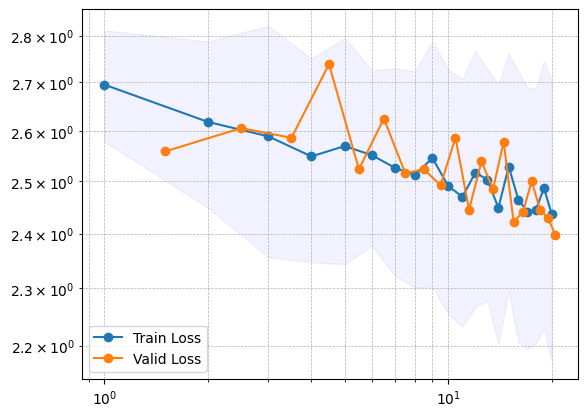

In [14]:
loaded = torch.load(f"contrastive_radar_infrared_pairs_20260529.pth")
radar_model.load_state_dict(loaded["radar_model"])
infrared_model.load_state_dict(loaded["infrared_model"])

optimizer.load_state_dict(loaded["optimizer"])
scheduler.load_state_dict(loaded["scheduler"])
train_losses = loaded["train_losses"]
valid_losses = loaded["valid_losses"]
# lrs = loaded["lrs"]

plot_losses(train_losses, valid_losses)

## Evaluation

In [15]:
def bucket_and_infer(objs, model, attr="points"):
    buckets = {}
    for i, o in enumerate(objs):
        buckets.setdefault(o.n_frames, {"objects": [], "indexes": []})
        buckets[o.n_frames]["objects"].append(o)
        buckets[o.n_frames]["indexes"].append(i)

    for nf in tqdm(buckets.keys(), desc=f"Inferring buckets for {attr}"):
        t = np.array([o.timestamps for o in buckets[nf]["objects"]])
        x = [getattr(o, attr) for o in buckets[nf]["objects"]]
        if attr == "landmarks":
            x = np.array(x)
        with torch.no_grad():
            buckets[nf]["embeddings"] = torch.nn.functional.normalize(model(x, timestamps=t, return_last_hidden_states=False).embedding, dim=-1).detach().cpu().float().numpy()

    flat = [None for _ in range(len(objs))]
    for nf in buckets.keys():
        for i, idx in enumerate(buckets[nf]["indexes"]):
            flat[idx] = buckets[nf]["embeddings"][i]

    return flat

In [16]:
test_df_c1 = path_dfs.test.obj[path_dfs.test.obj.campaign == "C1"].reset_index(drop=True).copy()
test_df_c2 = path_dfs.test.obj[path_dfs.test.obj.campaign == "C2"].reset_index(drop=True).copy()
test_df_c3 = path_dfs.test.obj[(path_dfs.test.obj.campaign == "C3") & (path_dfs.test.obj.user != "U41")].reset_index(drop=True).copy()
print(test_df_c1.shape, test_df_c1.radar_frame_count.nunique(), test_df_c1.infrared_frame_count.nunique())
print(test_df_c2.shape, test_df_c2.radar_frame_count.nunique(), test_df_c2.infrared_frame_count.nunique())
print(test_df_c3.shape, test_df_c3.radar_frame_count.nunique(), test_df_c3.infrared_frame_count.nunique())

(790, 8) 49 332
(400, 8) 29 189
(44, 8) 42 42


In [ ]:
def infer_emb_from_df(df, radar_model, infrared_model, trim=False):
    radar_objs, infrared_objs = load_uniform_instances(df, train=False, min_frames=20, max_frames=512, trim=trim)
    df["radar_embedding"]    = bucket_and_infer(radar_objs   , radar_model, attr="points")
    df["infrared_embedding"] = bucket_and_infer(infrared_objs, infrared_model, attr="landmarks")

random.seed(42)
radar_model.to("cuda").eval()
infrared_model.to("cuda").eval()

infer_emb_from_df(test_df_c1, radar_model, infrared_model)
infer_emb_from_df(test_df_c2, radar_model, infrared_model)
c3s = []
for i in range(8):
    copy = test_df_c3.copy()
    infer_emb_from_df(copy, radar_model, infrared_model, trim=True)
    copy.repetition=i+1
    c3s.append(copy)
test_df_c3 = pd.concat(c3s, ignore_index=True)
test_df = pd.concat([test_df_c1, test_df_c2, test_df_c3], ignore_index=True)

In [23]:
test_df = pd.concat([test_df_c1, test_df_c2, test_df_c3], ignore_index=True)
print(test_df.behavior.unique())
# test_df = test_df[test_df.behavior.isin(("M05", "A04"))]
print(test_df.shape)

['M05' 'M06' 'M15' 'M20' 'A04' 'A08' 'E02' 'E04']
(1542, 10)


In [50]:
def plot_similarity_matrices(r_emb, ir_emb, labels, users=None, reps=None):
    plt.subplots(1,3, figsize=(12,6))
    plt.suptitle(f"Embedding Similarities between classes\n({users} | Repetitions <= {reps})")
    plt.subplot(1,3,1)
    plt.title("Radar Embedding Similarity")
    plt.imshow(r_emb @ r_emb.T, vmax=1)
    if labels is not None:
        plt.xticks(range(len(labels)), labels, rotation=90)
        plt.yticks(range(len(labels)), labels)
    plt.subplot(1,3,2)
    plt.title("Infrared Embedding Similarity")
    plt.imshow(ir_emb @ ir_emb.T, vmax=1)
    if labels is not None:
        plt.xticks(range(len(labels)), labels, rotation=90)
        plt.yticks(range(len(labels)), labels)
    plt.subplot(1,3,3)
    plt.title("Cross-Modal Similarity")
    plt.imshow(r_emb @ ir_emb.T, vmax=1)
    if labels is not None:
        plt.xticks(range(len(labels)), labels, rotation=90)
        plt.yticks(range(len(labels)), labels)
    plt.xlabel("Infrared Embeddings")
    plt.ylabel("Radar Embeddings")
    plt.tight_layout()
    plt.show()

def print_report(y_true, preds, title, labels):
    print(title)
    print(classification_report(y_true, preds, zero_division=0))
    ConfusionMatrixDisplay.from_predictions(y_true, preds, labels=labels, xticks_rotation=90)
    plt.show()

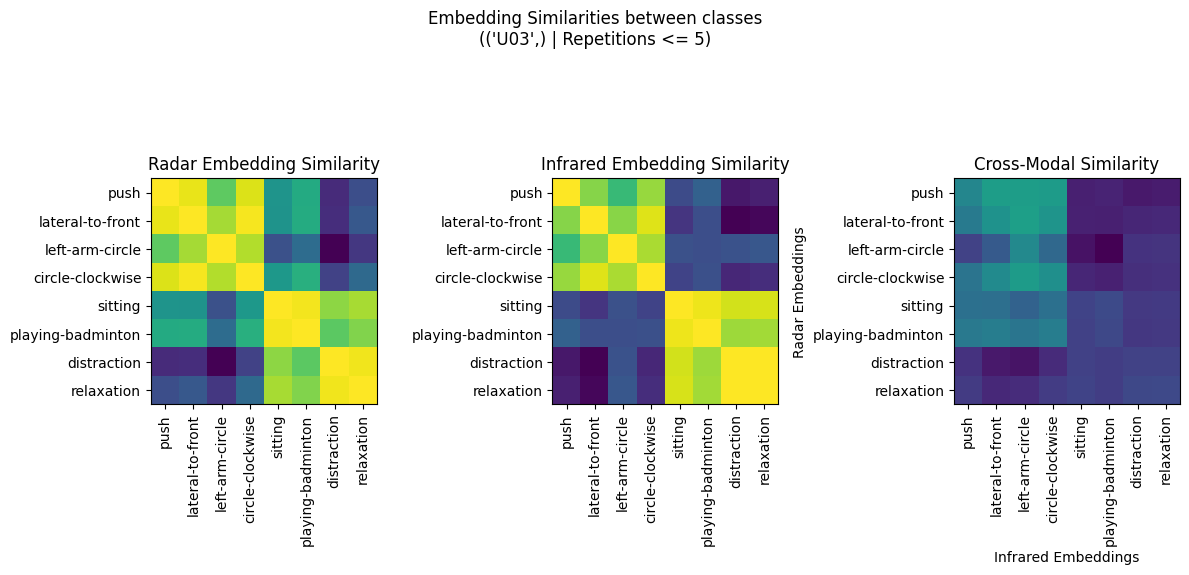

In [51]:
tgt_users = ("U03",)
tgt_reps  = 5
target_df = test_df[(test_df.user.isin(tgt_users)) & (test_df.repetition<=tgt_reps)][["campaign", "behavior", "radar_embedding", "infrared_embedding"]]
tgt_g     = target_df.groupby(["campaign", "behavior"]).mean() # todo: normalize

tgt_labels = np.array([map_to_name([b])[0] for c,b in tgt_g.radar_embedding.index.values.tolist()])
# tgt_labels = np.array([b for c,b in tgt_g.radar_embedding.index.values.tolist()])

tgt_r_emb = np.array(tgt_g.radar_embedding.values.tolist())
tgt_r_emb = tgt_r_emb / np.linalg.norm(tgt_r_emb, axis=-1, keepdims=True)

tgt_ir_emb = np.array(tgt_g.infrared_embedding.values.tolist())
tgt_ir_emb = tgt_ir_emb / np.linalg.norm(tgt_ir_emb, axis=-1, keepdims=True)

plot_similarity_matrices(tgt_r_emb, tgt_ir_emb, tgt_labels, tgt_users, tgt_reps)

In [52]:
input_df = test_df[~test_df.user.isin(tgt_users)][["campaign", "behavior", "radar_embedding", "infrared_embedding"]]
print(input_df.shape)

inp_labels = [map_to_name([b])[0] for b in input_df.behavior.values.tolist()]
# inp_labels = input_df.behavior.values.tolist()

inp_r_emb = np.array(input_df.radar_embedding.values.tolist())
inp_r_emb = inp_r_emb / np.linalg.norm(inp_r_emb, axis=-1, keepdims=True)

inp_ir_emb = np.array(input_df.infrared_embedding.values.tolist())
inp_ir_emb = inp_ir_emb / np.linalg.norm(inp_ir_emb, axis=-1, keepdims=True)

inp_r_emb.shape, inp_ir_emb.shape, inp_labels[:3]

(1478, 4)


((1478, 512), (1478, 512), ['push', 'push', 'push'])

In [53]:
r_r_pred = tgt_labels[(inp_r_emb  @ tgt_r_emb .T ).argmax(axis=-1)]  # todo: top-k (k-NN)
i_i_pred = tgt_labels[(inp_ir_emb @ tgt_ir_emb.T).argmax(axis=-1)]
r_i_pred = tgt_labels[(inp_r_emb  @ tgt_ir_emb.T).argmax(axis=-1)]
i_r_pred = tgt_labels[(inp_ir_emb @ tgt_r_emb .T ).argmax(axis=-1)]

Radar->Radar
                   precision    recall  f1-score   support

 circle-clockwise       0.21      0.04      0.07       178
      distraction       0.10      0.40      0.16       168
 lateral-to-front       0.68      0.06      0.12       201
  left-arm-circle       0.38      0.31      0.34       178
playing-badminton       0.44      0.24      0.31       192
             push       0.32      0.03      0.05       201
       relaxation       0.38      0.56      0.45       168
          sitting       0.48      0.51      0.49       192

         accuracy                           0.26      1478
        macro avg       0.37      0.27      0.25      1478
     weighted avg       0.38      0.26      0.25      1478



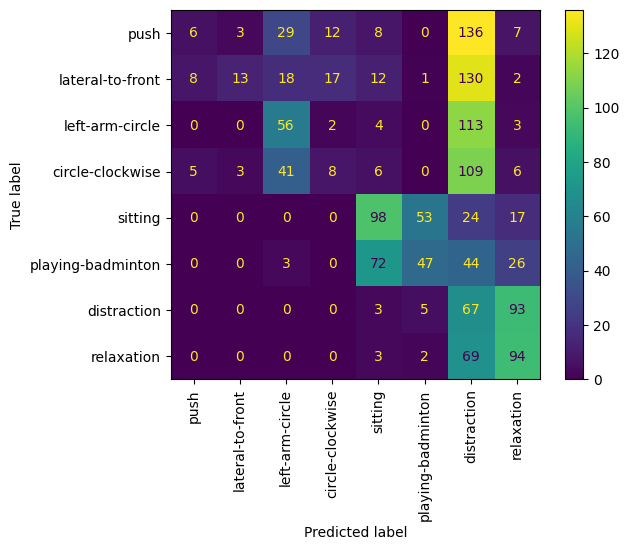

Infrared->Infrared
                   precision    recall  f1-score   support

 circle-clockwise       0.88      0.04      0.08       178
      distraction       0.20      0.15      0.17       168
 lateral-to-front       0.00      0.00      0.00       201
  left-arm-circle       0.26      0.28      0.27       178
playing-badminton       0.57      0.62      0.60       192
             push       0.30      0.48      0.37       201
       relaxation       0.39      0.90      0.55       168
          sitting       0.59      0.70      0.64       192

         accuracy                           0.40      1478
        macro avg       0.40      0.40      0.33      1478
     weighted avg       0.40      0.40      0.33      1478



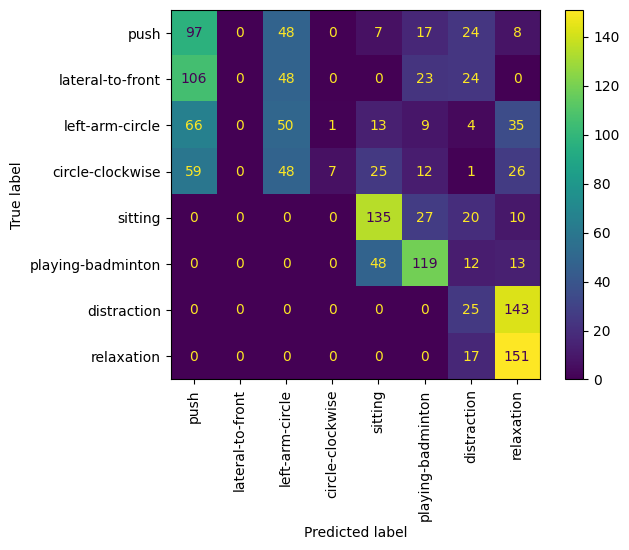

Radar->Infrared
                   precision    recall  f1-score   support

 circle-clockwise       0.02      0.01      0.01       178
      distraction       0.46      0.60      0.52       168
 lateral-to-front       0.05      0.01      0.02       201
  left-arm-circle       0.21      0.31      0.25       178
playing-badminton       0.02      0.03      0.02       192
             push       0.10      0.15      0.12       201
       relaxation       0.51      0.27      0.36       168
          sitting       0.05      0.03      0.04       192

         accuracy                           0.17      1478
        macro avg       0.18      0.18      0.17      1478
     weighted avg       0.17      0.17      0.16      1478



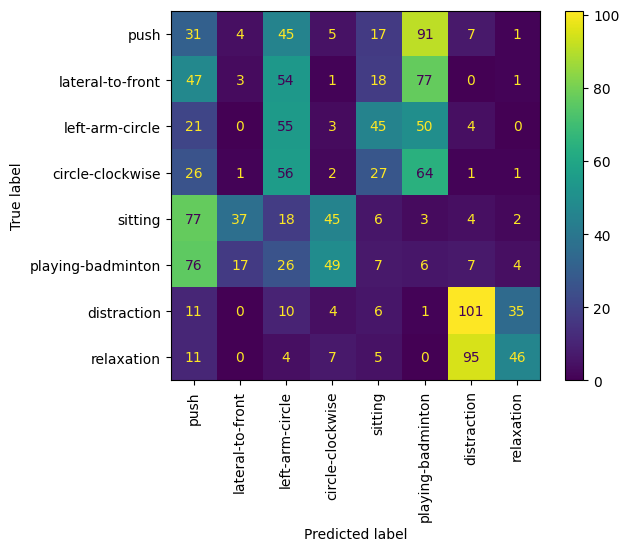

Infrared->Radar
                   precision    recall  f1-score   support

 circle-clockwise       0.00      0.00      0.00       178
      distraction       0.01      0.05      0.02       168
 lateral-to-front       0.40      0.04      0.07       201
  left-arm-circle       0.15      0.31      0.21       178
playing-badminton       1.00      0.02      0.04       192
             push       0.00      0.00      0.00       201
       relaxation       0.24      0.45      0.31       168
          sitting       0.10      0.05      0.06       192

         accuracy                           0.11      1478
        macro avg       0.24      0.12      0.09      1478
     weighted avg       0.24      0.11      0.09      1478



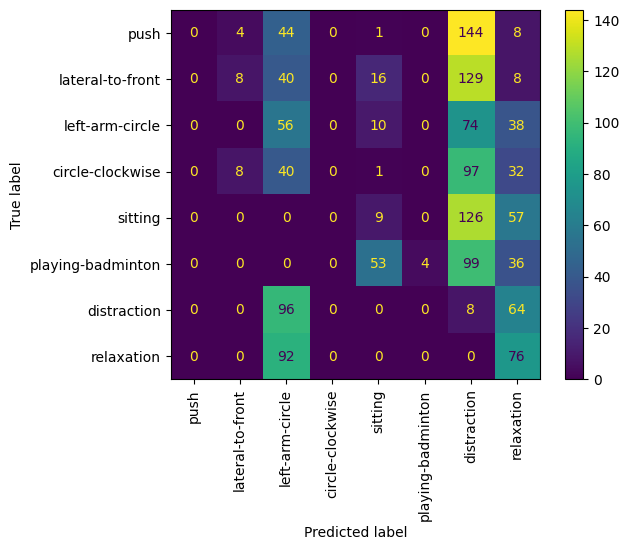

In [54]:
print_report(inp_labels, r_r_pred, "Radar->Radar", tgt_labels)
print_report(inp_labels, i_i_pred, "Infrared->Infrared", tgt_labels)
print_report(inp_labels, r_i_pred, "Radar->Infrared", tgt_labels)
print_report(inp_labels, i_r_pred, "Infrared->Radar", tgt_labels)